#**KNOWLEDGE GRAPH EXPLOITATION**

This is the notebook associated with the assignment **Knowledge Graph Exploitation**. In LearnSQL you can find the assignment statament, so please carefully read it while following the scripts, answering all the questions and compleating the tasks. Remember to change the **Runtime** settings to include GPU access.

Before starting, we will install and import the required libraries:

In [1]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pykeen
!pip install flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.8 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0

In [2]:
import torch
import numpy as np
from pykeen.triples import TriplesFactory
from torch_geometric.datasets import Planetoid
from pykeen.pipeline import pipeline
import pandas as pd
import itertools
from flaml import AutoML
from sklearn.metrics import f1_score
from torch import nn
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/30 08:58:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## **Creating the Knowledge Graph**

In [4]:
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

edge_index = data.edge_index

heads = edge_index[0].cpu().numpy()
tails = edge_index[1].cpu().numpy()

triples = np.array([
    [f"paper_{h}", "cites", f"paper_{t}"]
    for h, t in zip(heads, tails)
])

tf = TriplesFactory.from_labeled_triples(triples)

training, testing, validation = tf.split([0.8, 0.1, 0.1],random_state=2026)

Processing...
Done!


In [5]:
triples_array = torch.tensor(tf.mapped_triples)
cites_idx = tf.relation_to_id["cites"]

triples_set = set(map(tuple, triples_array.tolist()))
symmetric_count = sum(
    1 for (h, r, t) in triples_set
    if (t, r, h) in triples_set
)
print(f"Triple che hanno la loro inversa: {symmetric_count}")
print(f"Percentuale simmetrica: {100 * symmetric_count / tf.num_triples:.1f}%")

Triple che hanno la loro inversa: 88648
Percentuale simmetrica: 100.0%


/tmp/ipykernel_58/2022378485.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  triples_array = torch.tensor(tf.mapped_triples)


## **A.1 The Most Basic Model**




In [6]:
print("Training TransE model...")
pipeline_result = pipeline(
    training=training,
    testing=testing,
    validation=validation,
    model='TransE',
    epochs=25,
    device=device,
    random_seed=2026
)

model = pipeline_result.model

print("\nExtracting TransE embeddings...")
entity_embeddings = model.entity_representations[0](indices=None).detach().cpu()
relation_embeddings = model.relation_representations[0](indices=None).detach().cpu()

entity_to_id = training.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}
cites_idx = training.relation_to_id["cites"]

chosen_paper = "paper_100"
chosen_idx = entity_to_id[chosen_paper]

mapped_triples = training.mapped_triples
mask = (mapped_triples[:, 0] == chosen_idx) & (mapped_triples[:, 1] == cites_idx)
cited_paper_indices = mapped_triples[mask][:, 2]

if len(cited_paper_indices) == 0:
    print(f"Error: {chosen_paper} does not cite any papers in the training graph.")
else:
    cited_embeddings = entity_embeddings[cited_paper_indices]
    t_proxy = cited_embeddings.mean(dim=0)

    r_cites = relation_embeddings[cites_idx]
    ideal_vector = (t_proxy - r_cites).reshape(1, -1)

    distances = torch.cdist(ideal_vector, entity_embeddings, p=2).numpy().flatten()
    closest_indices = distances.argsort()

    for idx in closest_indices:
        if idx != chosen_idx:
            best_match_idx = idx
            break

    best_match_paper = id_to_entity[best_match_idx]
    best_match_distance = distances[best_match_idx]

    print(f"\nTarget Paper: {chosen_paper} (Cites {len(cited_paper_indices)} works)")
    print("-" * 50)
    print(f"Closest paper (citing similar works): {best_match_paper}")
    print(f"L2 Distance from ideal vector: {best_match_distance:.4f}")

Training TransE model...


Training epochs on cuda:0:   0%|          | 0/25 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 2.13s seconds



Extracting TransE embeddings...

Target Paper: paper_100 (Cites 2 works)
--------------------------------------------------
Closest paper (citing similar works): paper_3332
L2 Distance from ideal vector: 0.6603


## **A.2 Improving TransE**

See Section A.2 in the report

## **A.3 Training KGEs**

In [7]:
models_to_train = ['TransE', 'TransH', 'RotatE', 'DistMult']
trained_models = {}
metrics_summary = []

print("--- Starting Model Comparison ---")

for model_name in models_to_train:
    print(f"Training {model_name}...")

    result = pipeline(
        training=training,
        testing=testing,
        validation=validation,
        model=model_name,
        epochs=25,
        device=device,
        random_seed=2026
    )

    trained_models[model_name] = result.model
    metric_results = result.metric_results

    mrr = metric_results.get_metric('mrr')
    hits_at_1 = metric_results.get_metric('hits@1')
    hits_at_3 = metric_results.get_metric('hits@3')

    metrics_summary.append({
        'Model': model_name,
        'MRR': round(mrr, 4),
        'Hits@1': round(hits_at_1, 4),
        'Hits@3': round(hits_at_3, 4)
    })

results_df = pd.DataFrame(metrics_summary)
print("\n--- FINAL EVALUATION RESULTS ---")
print(results_df.to_string(index=False))

best_model_name = results_df.loc[results_df['MRR'].idxmax()]['Model']
best_model = trained_models[best_model_name]
print(f"\nBest performing model kept for downstream tasks: {best_model_name}")

INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


--- Starting Model Comparison ---
Training TransE...


Training epochs on cuda:0:   0%|          | 0/25 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.92s seconds



--- FINAL EVALUATION RESULTS ---
   Model    MRR  Hits@1  Hits@3
  TransE 0.0586  0.0000  0.0579
  TransH 0.0074  0.0013  0.0046
  RotatE 0.6529  0.5878  0.6866
DistMult 0.1552  0.0988  0.1707

Best performing model kept for downstream tasks: RotatE


In [8]:
test = False
if test:
  print(f"--- Starting Full Grid Search for: {best_model_name} ---")
  print("Note: This will execute 27 separate training runs.\n")

  exploration_results = []

  dimensions = [32, 128, 256]
  neg_samples = [1, 5, 15]
  margins = [0.5, 1.0, 5.0]

  all_combinations = list(itertools.product(dimensions, neg_samples, margins))

  for dim, neg, margin in all_combinations:
      print(f"Testing Combo -> Dim: {dim} | Negs: {neg} | Margin: {margin} ...")

      res = pipeline(
          training=training,
          testing=testing,
          validation=validation,
          model=best_model_name,
          epochs=25,
          device=device,
          random_seed=2026,
          model_kwargs={'embedding_dim': dim},
          negative_sampler_kwargs={'num_negs_per_pos': neg},
          loss_kwargs={'margin': margin}
      )

      mrr = res.metric_results.get_metric('mrr')

      exploration_results.append({
          'Dimension': dim,
          'Neg Samples': neg,
          'Margin': margin,
          'MRR': round(mrr, 4)
      })

  exploration_df = pd.DataFrame(exploration_results)
  exploration_df = exploration_df.sort_values(by='MRR', ascending=False).reset_index(drop=True)

  print("\n--- FULL GRID SEARCH RESULTS ---")
  print(exploration_df.to_string())

In [9]:
print("Training the final optimized RotatE model for downstream tasks...")

final_result = pipeline(
    training=training,
    testing=testing,
    validation=validation,
    model='RotatE',
    epochs=25,
    device=device,
    random_seed=2026,
    model_kwargs={'embedding_dim': 256},
    negative_sampler_kwargs={'num_negs_per_pos': 15},
    loss_kwargs={'margin': 0.5}
)

best_model = final_result.model

final_mrr = final_result.metric_results.get_metric('mrr')
final_hits_at_1 = final_result.metric_results.get_metric('hits@1')
final_hits_at_3 = final_result.metric_results.get_metric('hits@3')

print("-" * 40)
print("Final Optimized Model Trained!")
print(f"MRR:    {final_mrr:.4f}")
print(f"Hits@1: {final_hits_at_1:.4f}")
print(f"Hits@3: {final_hits_at_3:.4f}")
print("-" * 40)

print("Extracting and aligning KGE embeddings for PyTorch Geometric...")

entity_mapping = training.entity_to_id

kge_raw_embeddings = best_model.entity_representations[0](indices=None).detach().cpu()
embedding_dim = kge_raw_embeddings.shape[1]

num_nodes = dataset[0].num_nodes

ordered_embeddings = torch.zeros((num_nodes, embedding_dim))

missing_nodes = 0
for pyg_node_id in range(num_nodes):
    entity_label = str(pyg_node_id)

    if entity_label in entity_mapping:
        pykeen_id = entity_mapping[entity_label]
        ordered_embeddings[pyg_node_id] = kge_raw_embeddings[pykeen_id]
    else:
        ordered_embeddings[pyg_node_id] = torch.randn(embedding_dim)
        missing_nodes += 1

torch.save(ordered_embeddings, 'kge_embeddings.pt')

print(f"Saved {num_nodes} ordered embeddings to 'kge_embeddings.pt'.")
print(f"Isolated nodes filled with random noise: {missing_nodes}")
print("Ready for Part B: Graph Neural Networks.")

INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training the final optimized RotatE model for downstream tasks...


Training epochs on cuda:0:   0%|          | 0/25 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 9.39s seconds


----------------------------------------
Final Optimized Model Trained!
MRR:    0.7867
Hits@1: 0.7545
Hits@3: 0.8099
----------------------------------------
Extracting and aligning KGE embeddings for PyTorch Geometric...
Saved 19717 ordered embeddings to 'kge_embeddings.pt'.
Isolated nodes filled with random noise: 19717
Ready for Part B: Graph Neural Networks.


In [10]:
train_triples_set = set(map(tuple, training.mapped_triples.tolist()))
test_triples_set = set(map(tuple, testing.mapped_triples.tolist()))

cross_split_symmetric_count = sum(
    1 for (h, r, t) in test_triples_set
    if (t, r, h) in train_triples_set
)

test_size = len(test_triples_set)
percentage = (cross_split_symmetric_count / test_size) * 100

print(f"The {percentage:.1f}% of the test set has its symmetry in the train set.")

The 80.5% of the test set has its symmetry in the train set.


## **A.4 Negative Sampling**

In [11]:
training_triples = training.mapped_triples.numpy()

train_heads = training_triples[:, 0]
train_tails = training_triples[:, 2]

num_triples = len(train_heads)
unique_heads = len(np.unique(train_heads))
unique_tails = len(np.unique(train_tails))

tph = num_triples / unique_heads
hpt = num_triples / unique_tails

bernoulli_p_head = tph / (tph + hpt)
bernoulli_p_tail = hpt / (tph + hpt)

print(f"Uniform P(Corrupt Head):   0.5000")
print(f"Bernoulli P(Corrupt Head): {bernoulli_p_head:.4f}")
print("-" * 35)
print(f"Uniform P(Corrupt Tail):   0.5000")
print(f"Bernoulli P(Corrupt Tail): {bernoulli_p_tail:.4f}")

Uniform P(Corrupt Head):   0.5000
Bernoulli P(Corrupt Head): 0.4681
-----------------------------------
Uniform P(Corrupt Tail):   0.5000
Bernoulli P(Corrupt Tail): 0.5319


## **Loading the full PubMed Dataset**

In [12]:
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

print(data)
print("Number of node features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)

data = data.to('cuda' if torch.cuda.is_available() else 'cpu')

Data(x=[19717, 500], edge_index=[2, 88648], y=[19717], train_mask=[19717], val_mask=[19717], test_mask=[19717])
Number of node features: 500
Number of classes: 3


## **B.1: Let's Forget About the Graph**

With the dataset above, train three or four simple classifiers (e.g., SVM, LR, RF, KNN...) and report the accuracy score over the test set for them.

*Note: use **sklearn** for simplicity.*

In [13]:
X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

train_mask = data.train_mask.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Training set size: {X_train.shape[0]} nodes")
print(f"Test set size:   {X_test.shape[0]} nodes")

print("\nStarting AutoML training (Budget: 60 seconds)...")
automl = AutoML()
automl_settings = {
    "time_budget": 60,
    "metric": 'macro_f1',
    "task": 'classification',
    "estimator_list": ['rf', 'lrl1', 'lrl2', 'svc'],
    "verbose": 0,
    "seed": 2026,
    "n_jobs": 1
}

automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

y_pred = automl.predict(X_test)

test_f1 = f1_score(y_test, y_pred, average='macro')

print("-" * 50)
print(f"Best Model Selected:   {automl.best_estimator}")
print(f"Best Hyperparameters:  {automl.best_config}")
print(f"Final Test Macro F1:   {test_f1:.4f}")
print("-" * 50)

Training set size: 60 nodes
Test set size:   1000 nodes

Starting AutoML training (Budget: 60 seconds)...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


--------------------------------------------------
Best Model Selected:   rf
Best Hyperparameters:  {'n_estimators': 31, 'max_features': np.float64(0.14321472986783276), 'max_leaves': 8, 'criterion': np.str_('entropy')}
Final Test Macro F1:   0.7224
--------------------------------------------------


## **B.2: Exploiting the Graph Structure**

Now, we are going to create a GNN with graph layers and a final linear layer. Refer to the Lab Statement for more details of how to implement the architecture. You should report your designed architecutre(s) and the accuracy results.

In [14]:
class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)

        self.conv2 = GCNConv(hidden_channels, 256)

        self.linear = nn.Linear(256, out_channels)

        self.dropout_rate = 0.7

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        if return_embeddings:
            return x

        x = self.linear(x)

        return x

In [15]:
gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device)

optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)

def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, f1

print("Training GNN for 500 epochs...")
for epoch in range(500):
    loss = train_gnn(gnn_model)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

gnn_acc, gnn_f1 = test_gnn(gnn_model)

print("-" * 40)
print("Training Complete!")
print(f"Test Accuracy: {gnn_acc:.4f}")
print(f"Test Macro F1: {gnn_f1:.4f}")
print("-" * 40)

Training GNN for 500 epochs...
Epoch 000 | Loss: 1.0997
Epoch 050 | Loss: 0.0090
Epoch 100 | Loss: 0.0270
Epoch 150 | Loss: 0.0160
Epoch 200 | Loss: 0.0014
Epoch 250 | Loss: 0.0144
Epoch 300 | Loss: 0.0060
Epoch 350 | Loss: 0.0108
Epoch 400 | Loss: 0.0059
Epoch 450 | Loss: 0.0086
----------------------------------------
Training Complete!
Test Accuracy: 0.7790
Test Macro F1: 0.7717
----------------------------------------


## **B.4: The More the Merrier?**

Create new GNN models with 2, 4, 8 and 16 GNN layers and report the accuracy results. What do you observe? Why do you think it is happening?

In [16]:
class DeepGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super().__init__()

        self.convs = nn.ModuleList()

        if num_layers == 1:
            self.convs.append(GCNConv(in_channels, 256))
        else:
            self.convs.append(GCNConv(in_channels, hidden_channels))
            for _ in range(num_layers - 2):
                self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.convs.append(GCNConv(hidden_channels, 256))

        self.linear = nn.Linear(256, out_channels)
        self.dropout_rate = 0.7

    def forward(self, x, edge_index, return_embeddings=False):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout_rate, training=self.training)

        if return_embeddings:
            return x

        x = self.linear(x)
        return x

layers_to_test = [2, 4, 8, 16]
results = {}

for num_layers in layers_to_test:
    print(f"\n--- Training GNN with {num_layers} layers ---")

    model = DeepGNN(dataset.num_node_features, 256, dataset.num_classes, num_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    def train_gnn(model):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        return loss.item()

    @torch.no_grad()
    def test_gnn(model):
        model.eval()
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)

        correct = pred[data.test_mask] == data.y[data.test_mask]
        acc = int(correct.sum()) / int(data.test_mask.sum())

        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = pred[data.test_mask].cpu().numpy()
        f1 = f1_score(y_true, y_pred, average='macro')

        return acc, f1

    for epoch in range(500):
        train_gnn(model)

    final_acc, final_f1 = test_gnn(model)
    results[num_layers] = {'acc': final_acc, 'f1': final_f1}

    print(f"Final Test Accuracy: {final_acc:.4f}")
    print(f"Final Test Macro F1: {final_f1:.4f}")


--- Training GNN with 2 layers ---
Final Test Accuracy: 0.7630
Final Test Macro F1: 0.7581

--- Training GNN with 4 layers ---
Final Test Accuracy: 0.7510
Final Test Macro F1: 0.7457

--- Training GNN with 8 layers ---
Final Test Accuracy: 0.5030
Final Test Macro F1: 0.4702

--- Training GNN with 16 layers ---
Final Test Accuracy: 0.2760
Final Test Macro F1: 0.2239


## **B.5: What if we do  not have Initial Information?**

Train your previosuly best performing model with randomly initialized features and report the results:

In [17]:
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

data.x = torch.randn(data.num_nodes, 256)
data = data.to(device)

random_gnn_model = GNN(in_channels=256, hidden_channels=256, out_channels=dataset.num_classes).to(device)

optimizer = torch.optim.Adam(random_gnn_model.parameters(), lr=0.01, weight_decay=5e-4)

def train_random_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_random_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, f1

print("Training GNN with 256-D RANDOM initialization for 500 epochs...")
for epoch in range(500):
    loss = train_random_gnn(random_gnn_model)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.6f}")

final_acc_rand, final_f1_rand = test_random_gnn(random_gnn_model)

print("-" * 40)
print("Training Complete!")
print(f"Test Accuracy (Random Init): {final_acc_rand:.6f}")
print(f"Test Macro F1 (Random Init):   {final_f1_rand:.6f}")
print("-" * 40)

Training GNN with 256-D RANDOM initialization for 500 epochs...
Epoch 000 | Loss: 1.113893
Epoch 050 | Loss: 0.051448
Epoch 100 | Loss: 0.000893
Epoch 150 | Loss: 0.007861
Epoch 200 | Loss: 0.003297
Epoch 250 | Loss: 0.000068
Epoch 300 | Loss: 0.004278
Epoch 350 | Loss: 0.000000
Epoch 400 | Loss: 0.204397
Epoch 450 | Loss: 0.000000
----------------------------------------
Training Complete!
Test Accuracy (Random Init): 0.383000
Test Macro F1 (Random Init):   0.358122
----------------------------------------


Now, we will see how to initialize the GNN with the embeddings resulting from a Knowledge Graph Embedding Model.

In [18]:
data = dataset[0]

kge_embeddings = torch.load('kge_embeddings.pt')

data.x = kge_embeddings
data = data.to(device)

Now, train again a GNN with the TransE embeddings as initialization:

In [19]:
kge_gnn_model = GNN(in_channels=kge_embeddings.shape[1], hidden_channels=256, out_channels=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(kge_gnn_model.parameters(), lr=0.01, weight_decay=5e-4)

def train_kge_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_kge_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, f1

print("Training GNN with KGE initialization for 500 epochs...")
for epoch in range(500):
    loss = train_kge_gnn(kge_gnn_model)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

final_acc_kge, final_f1_kge = test_kge_gnn(kge_gnn_model)

print("-" * 40)
print("Training Complete!")
print(f"Test Accuracy (KGE Init): {final_acc_kge:.4f}")
print(f"Test Macro F1 (KGE Init):   {final_f1_kge:.4f}")
print("-" * 40)

Training GNN with KGE initialization for 500 epochs...
Epoch 000 | Loss: 1.0957
Epoch 050 | Loss: 0.1799
Epoch 100 | Loss: 0.0046
Epoch 150 | Loss: 0.0253
Epoch 200 | Loss: 0.0001
Epoch 250 | Loss: 0.0034
Epoch 300 | Loss: 0.1477
Epoch 350 | Loss: 0.0000
Epoch 400 | Loss: 0.0004
Epoch 450 | Loss: 0.0000
----------------------------------------
Training Complete!
Test Accuracy (KGE Init): 0.3800
Test Macro F1 (KGE Init):   0.3672
----------------------------------------


## **B.7: Where are the Embeddings?**

In this task we will obtaint the embeddings generated by our GNN architecture. First, update and retrain you best performing GNN model so that it returns the embeddings (see the lab statement for details).

In [20]:
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

print(data)
print("Number of node features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)

data = data.to('cuda' if torch.cuda.is_available() else 'cpu')

Data(x=[19717, 500], edge_index=[2, 88648], y=[19717], train_mask=[19717], val_mask=[19717], test_mask=[19717])
Number of node features: 500
Number of classes: 3


In [21]:
class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)

        self.conv2 = GCNConv(hidden_channels, 256)

        self.linear = nn.Linear(256, out_channels)

        self.dropout_rate = 0.7

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        if return_embeddings:
            return x

        x = self.linear(x)

        return x

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device)

optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)

def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, f1

print("Training GNN for 500 epochs...")
for epoch in range(500):
    loss = train_gnn(gnn_model)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

gnn_acc, gnn_f1 = test_gnn(gnn_model)

print("-" * 40)
print("Training Complete!")
print(f"Test Accuracy: {gnn_acc:.4f}")
print(f"Test Macro F1: {gnn_f1:.4f}")
print("-" * 40)

Training GNN for 500 epochs...
Epoch 000 | Loss: 1.0978
Epoch 050 | Loss: 0.0114
Epoch 100 | Loss: 0.0168
Epoch 150 | Loss: 0.0151
Epoch 200 | Loss: 0.0134
Epoch 250 | Loss: 0.0078
Epoch 300 | Loss: 0.0127
Epoch 350 | Loss: 0.0073
Epoch 400 | Loss: 0.0052
Epoch 450 | Loss: 0.0054
----------------------------------------
Training Complete!
Test Accuracy: 0.7580
Test Macro F1: 0.7569
----------------------------------------


Obtain the embeddings:

In [22]:
gnn_model.eval()

with torch.no_grad():
    embs = gnn_model(data.x, data.edge_index, return_embeddings=True)

embs = embs.cpu().numpy()

print(f"Successfully extracted embeddings with shape: {embs.shape}")

Successfully extracted embeddings with shape: (19717, 256)


Once you have obtained the embeddings, apply dimensionality reduction (e.g., PCA) and visualize the result by coloring each embedding with its corresponding class.

/tmp/ipykernel_58/1652720050.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', n_classes)
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


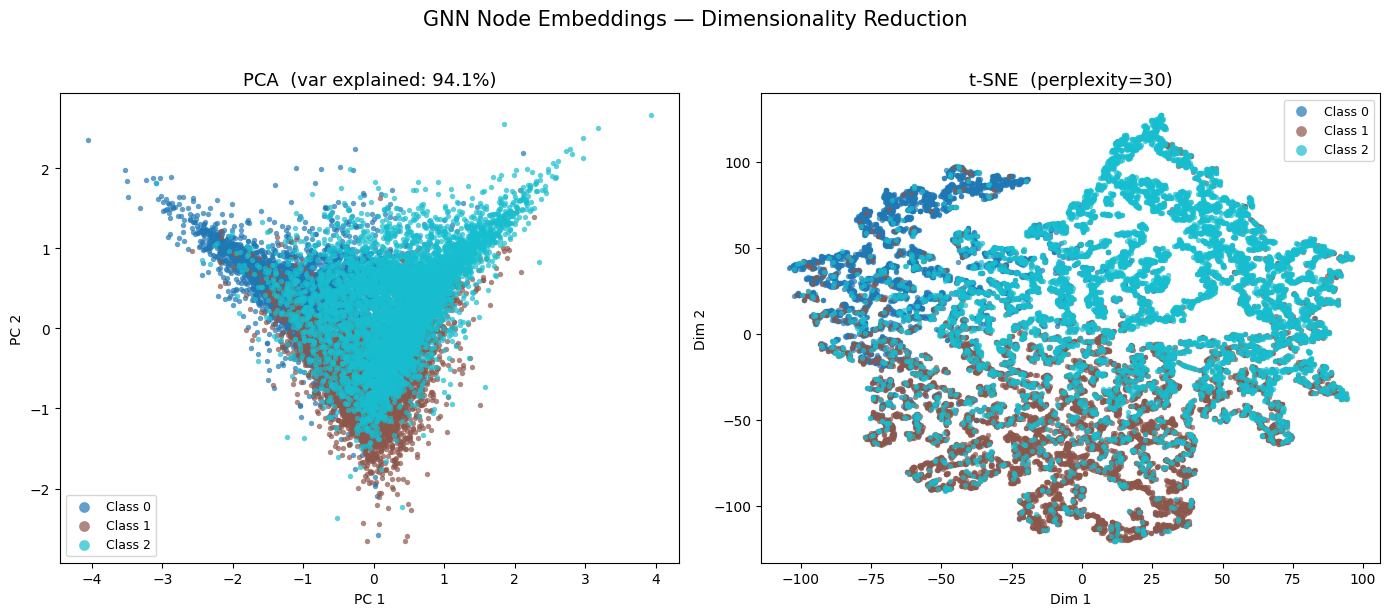

PCA explained variance: [0.5448537  0.39645964]


In [23]:
labels = data.y.cpu().numpy()
n_classes = len(np.unique(labels))
colors = cm.get_cmap('tab10', n_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pca = PCA(n_components=2, random_state=42)
embs_pca = pca.fit_transform(embs)

for cls in range(n_classes):
    mask = labels == cls
    axes[0].scatter(
        embs_pca[mask, 0], embs_pca[mask, 1],
        c=[colors(cls)], label=f'Class {cls}',
        alpha=0.7, s=15, linewidths=0
    )
axes[0].set_title(
    f'PCA  (var explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)',
    fontsize=13
)
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=2, fontsize=9)

n_pre = min(50, embs.shape[1])
embs_pre = PCA(n_components=n_pre, random_state=42).fit_transform(embs)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init='pca',
    learning_rate='auto'
)
embs_tsne = tsne.fit_transform(embs_pre)

for cls in range(n_classes):
    mask = labels == cls
    axes[1].scatter(
        embs_tsne[mask, 0], embs_tsne[mask, 1],
        c=[colors(cls)], label=f'Class {cls}',
        alpha=0.7, s=15, linewidths=0
    )
axes[1].set_title(f't-SNE  (perplexity=30)', fontsize=13)
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')
axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle('GNN Node Embeddings — Dimensionality Reduction', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('embeddings_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_}")

## **B.8 Embedding spaces**

### **B.8 Task: Finding similar papers in the embedding space**

We will follow these steps:
1. Extract embeddings from the trained GNN model.
2. Pick a reference paper index.
3. Find all papers cited by this paper using the `edge_index`.
4. Calculate the centroid (mean) of those neighbors' embeddings.
5. Find the paper in the dataset whose embedding has the highest cosine similarity to this centroid.

In [24]:
gnn_model.eval()
with torch.no_grad():
    all_embs = gnn_model(data.x, data.edge_index, return_embeddings=True).cpu().numpy()

target_paper_idx = 100
print(f"Target Paper Index: {target_paper_idx}")

mask = data.edge_index[0] == target_paper_idx
cited_indices = data.edge_index[1][mask].cpu().numpy()

if len(cited_indices) > 0:
    cited_embs = all_embs[cited_indices]
    mean_citation_vector = cited_embs.mean(axis=0).reshape(1, -1)

    similarities = cosine_similarity(mean_citation_vector, all_embs).flatten()

    closest_paper_idx = similarities.argmax()

    print(f"Number of papers cited by target: {len(cited_indices)}")
    print(f"Closest paper index to the citation profile: {closest_paper_idx}")
    print(f"Similarity score: {similarities[closest_paper_idx]:.4f}")
else:
    print("The chosen paper has no outgoing citations in the edge_index.")

Target Paper Index: 100
Number of papers cited by target: 2
Closest paper index to the citation profile: 13763
Similarity score: 0.9980


In [25]:
def top_k_neighbors(embs: np.ndarray, idx: int, k: int = 10):
    """Return top-k neighbor indices and their cosine similarities."""
    sims = cosine_similarity(embs[idx].reshape(1, -1), embs).flatten()
    sims[idx] = -np.inf
    top_k = np.argsort(sims)[::-1][:k]
    return top_k, sims[top_k]

P = 100

nn_gnn, sim_gnn = top_k_neighbors(all_embs, P, k=10)
nn_kge, sim_kge = top_k_neighbors(kge_embeddings, P, k=10)

overlap = set(nn_gnn) & set(nn_kge)
jaccard = len(overlap) / len(set(nn_gnn) | set(nn_kge))

print(f"{'='*55}")
print(f"Target paper index : {P}")
print(f"{'='*55}")
print(f"\n[GNN] Top-10 neighbors:")
for rank, (idx, s) in enumerate(zip(nn_gnn, sim_gnn), 1):
    print(f"  {rank:2d}. paper {idx:5d}  (cos_sim = {s:.4f})")

print(f"\n[KGE] Top-10 neighbors:")
for rank, (idx, s) in enumerate(zip(nn_kge, sim_kge), 1):
    print(f"  {rank:2d}. paper {idx:5d}  (cos_sim = {s:.4f})")

print(f"\n{'='*55}")
print(f"Overlap          : {sorted(overlap)}  ({len(overlap)}/10 papers)")
print(f"Jaccard index    : {jaccard:.3f}")
print(f"{'='*55}")

Target paper index : 100

[GNN] Top-10 neighbors:
   1. paper  7142  (cos_sim = 1.0000)
   2. paper 16886  (cos_sim = 1.0000)
   3. paper 15371  (cos_sim = 1.0000)
   4. paper 12705  (cos_sim = 1.0000)
   5. paper  8085  (cos_sim = 0.9999)
   6. paper 17082  (cos_sim = 0.9999)
   7. paper 15784  (cos_sim = 0.9999)
   8. paper 10410  (cos_sim = 0.9999)
   9. paper   860  (cos_sim = 0.9999)
  10. paper 16591  (cos_sim = 0.9999)

[KGE] Top-10 neighbors:
   1. paper  6069  (cos_sim = 0.2334)
   2. paper 15325  (cos_sim = 0.2309)
   3. paper 12341  (cos_sim = 0.2292)
   4. paper 13245  (cos_sim = 0.2267)
   5. paper  4142  (cos_sim = 0.2181)
   6. paper 19162  (cos_sim = 0.2010)
   7. paper 13519  (cos_sim = 0.2006)
   8. paper  5124  (cos_sim = 0.1996)
   9. paper 12082  (cos_sim = 0.1995)
  10. paper  9733  (cos_sim = 0.1936)

Overlap          : []  (0/10 papers)
Jaccard index    : 0.000
